<a href="https://colab.research.google.com/github/tarang321/ML-Hardware/blob/main/Copy_of_NumpyTFandVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numpy, TF, and Visualization

## Start by importing necessary packages
We will begin by importing necessary libraries for this notebook. Run the cell below to do so.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import tensorflow as tf

## Visualizations

Visualization is a key factor in understanding deep learning models and their behavior. Typically, pyplot from the matplotlib package is used, capable of visualizing series and 2D data.

Below is an example of visualizing series data.

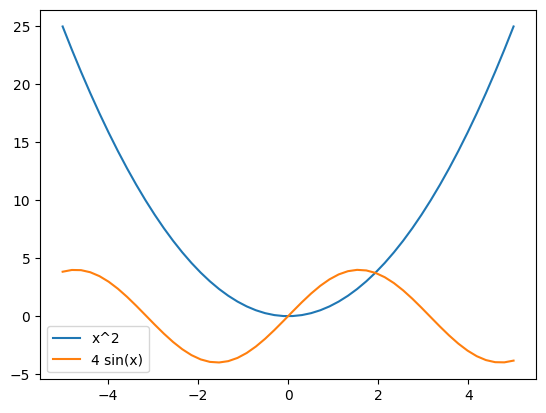

In [ ]:
x = np.linspace(-5, 5, 50) # create a linear spacing from x = -5.0 to 5.0 with 50 steps

y1 = x**2        # create a series of points {y1}, which corresponds to the function f(x) = y^2
y2 = 4*np.sin(x) # create another series of points {y2}, which corresponds to the function f(x) = 4*sin(x)
                 # NOTE: we have to use np.sin and not math.sin as math.sin will only act on individual values
                 # to use math.sin, we could have used a list comprehension instead: y2 = [math.sin(xi) for xi in x]

                 # by default, matplotlib will behave like MATLAB with hold(True), overplotting until a new figure object is created
plt.plot(x, y1, label="x^2")        # plot y1 with x as the x-axis series, and label the line "x^2"
plt.plot(x, y2, label="4 sin(x)")   # plot y2 with x as the x-axis series, and label the line "4 sin(x)"
plt.legend()                        # have matplotlib show the label on the plot

More complex formatting can be added to increase the visual appeal and readability of plots (especially for paper quality figures).
To try this out, let's consider plotting a few of the more common activation functions used in machine learning.

**Question 1**

In the cell below, plot the following activation functions for $x\in[-4, 4]$:

*   ReLU: $max(x, 0)$
*   Leaky-ReLU: $max(0.1\cdot x, x)$
*   Sigmoid: $\sigma(x) = 1/(1 + e^{-x})$
*   Hyperbolic Tangent: $\mathrm{tanh}(x) = (e^{x} - e^{-x})/(e^{x} + e^{-x})$
*   SiLU: $x \cdot \sigma(x)$
*   GeLU: $x \cdot \frac{1}{2} \left(1 + \mathrm{erf}\left(\frac{x}{\sqrt{2}}\right)\right)$
*   tanh GELU: $x \cdot \frac{1}{2} \left(1 + \mathrm{tanh}\left(\frac{x}{\sqrt{2}}\right)\right)$

For GELU and tanh GELU use the same color, but for tanh use a dashed line (tanh is a common approximation as the error-function is computationally expensive to compute).

You may need to adjust the legend to make it easier to read.

I recommend using ChatGPT to help find the formatting options here.


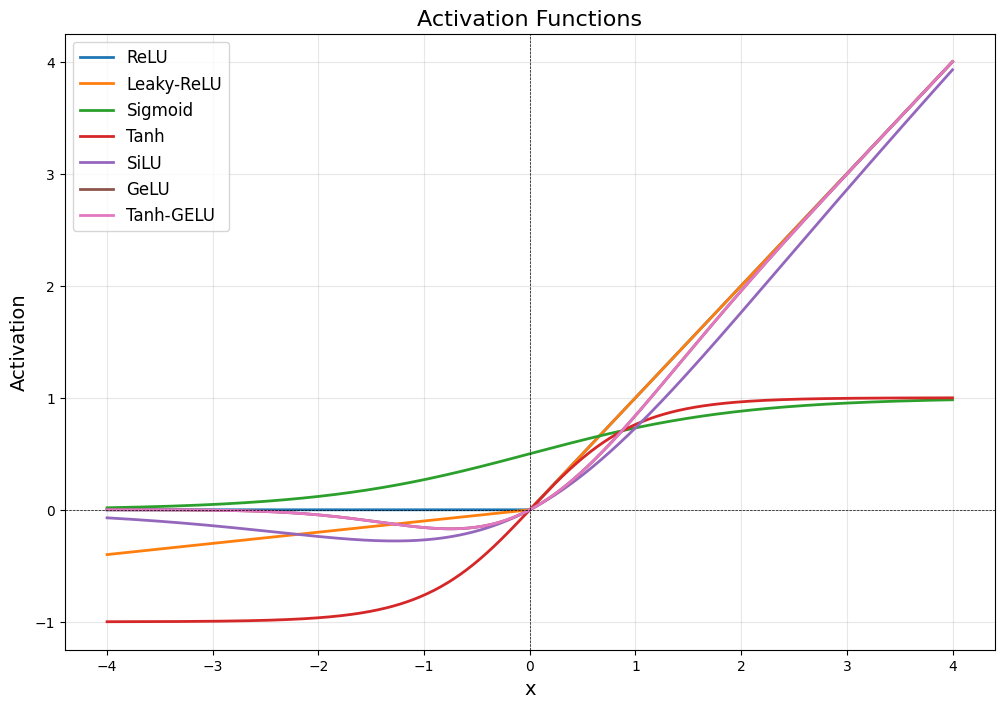

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Define activation functions
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.maximum(alpha * x, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def silu(x):
    return x * sigmoid(x)

def gelu(x):
    return x * 0.5 * (1 + erf(x / np.sqrt(2)))

def tanh_gelu(x):
    return x * 0.5 * (1 + tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

# Generate x values
x = np.linspace(-4, 4, 500)

# Compute y values for each function
y_relu = relu(x)
y_leaky_relu = leaky_relu(x)
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_silu = silu(x)
y_gelu = gelu(x)
y_tanh_gelu = tanh_gelu(x)

# Plot the functions
plt.figure(figsize=(12, 8))
plt.plot(x, y_relu, label='ReLU', linewidth=2)
plt.plot(x, y_leaky_relu, label='Leaky-ReLU', linewidth=2)
plt.plot(x, y_sigmoid, label='Sigmoid', linewidth=2)
plt.plot(x, y_tanh, label='Tanh', linewidth=2)
plt.plot(x, y_silu, label='SiLU', linewidth=2)
plt.plot(x, y_gelu, label='GeLU', linewidth=2)
plt.plot(x, y_tanh_gelu, label='Tanh-GELU', linewidth=2)

# Add labels, legend, and grid
plt.title("Activation Functions", fontsize=16)
plt.xlabel("x", fontsize=14)
plt.ylabel("Activation", fontsize=14)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()


**Question 2**

Answer the following from the the plot you just created above:

1.   Which activation function is the least computationally expensive to compute?
2.   Are there better choices to ensure more stable training? What downfalls do you think it may have?
3.   Are there any cases where you would not want to use either activation function?


1. **Least computationally expensive:** ReLU (\(\max(x, 0)\)).

2. **Better choices for stable training:** GeLU, Tanh-GELU, and SiLU.  
   **Downfalls:** Computationally expensive; Sigmoid and Tanh can cause vanishing gradients.

3. **Cases to avoid:**
   - **ReLU:** When "dead neurons" might occur.  
   - **Leaky-ReLU:** Improper \(\alpha\) choice can degrade performance.  
   - **Sigmoid/Tanh:** In deep networks due to vanishing gradients.

### Visualizing 2D data

In many cases, we also want the ability to visualize multi-dimensional data such as images. To do so, matplotlib has the imshow method, which can visualize single channel data with a heatmap, or RGB data with color.

Let's consider visualizing the first 8 training images from the MNIST dataset. MNIST consists of hand drawn digits with their corresponding labels (a number from 0 to 9).

We will use the tensorflow keras dataset library to load the dataset, and then visualize the images with a matplotlib subplot.
Because we have so many images, we should arrange them in a grid (4 horizontal, 2 vertical), and plot each image in a loop.
Furthermore, we can append the label to each image using the matplotlib utility.


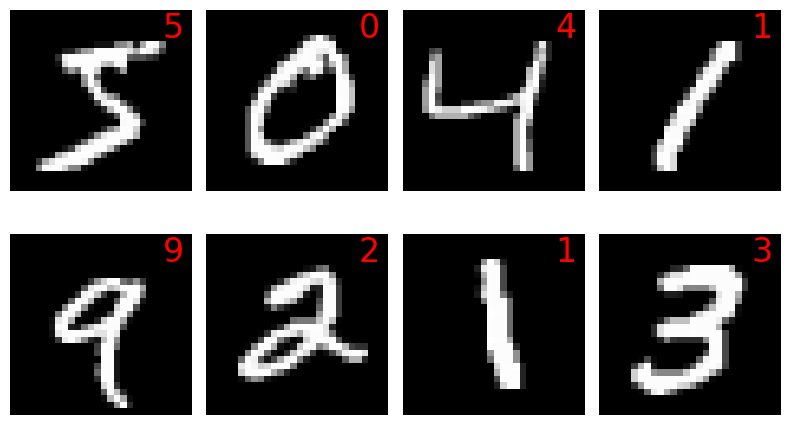

In [ ]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Define the grid dimensions
rows, cols = 2, 4

# Create a figure and axes for the grid
fig, axes = plt.subplots(rows, cols, figsize=(8, 5))

# Iterate through the grid
for i in range(rows):
    for j in range(cols):
        index = i * cols + j
        ax = axes[i, j]

        # Display the image
        ax.imshow(train_images[index], cmap='gray')

        # Display the label on top of the image in red text
        ax.text(0.9, 0.9, str(train_labels[index]), color='red',
                transform=ax.transAxes, fontsize=24,
                ha='center', va='center')

        # Turn off axis labels
        ax.axis('off')

# Adjust spacing and layout
plt.tight_layout()

**Question 3**

Another popular image dataset for benchmarking and evaluation is CIFAR-10. This dataset consists of small (32 x 32 pixel) RGB images of objects that fall into one of 10 classes:

0.   airplane
1.   automobile
2.   bird
3.   cat
4.   deer
5.   dog
6.   frog
7.   horse
8.   ship
9.  truck

In the cell below please plot the first 32 images in the dataset using a similar method to the one used for MNIST.

Again, please use ChatGPT to guide you with the formatting and syntax as necessary.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


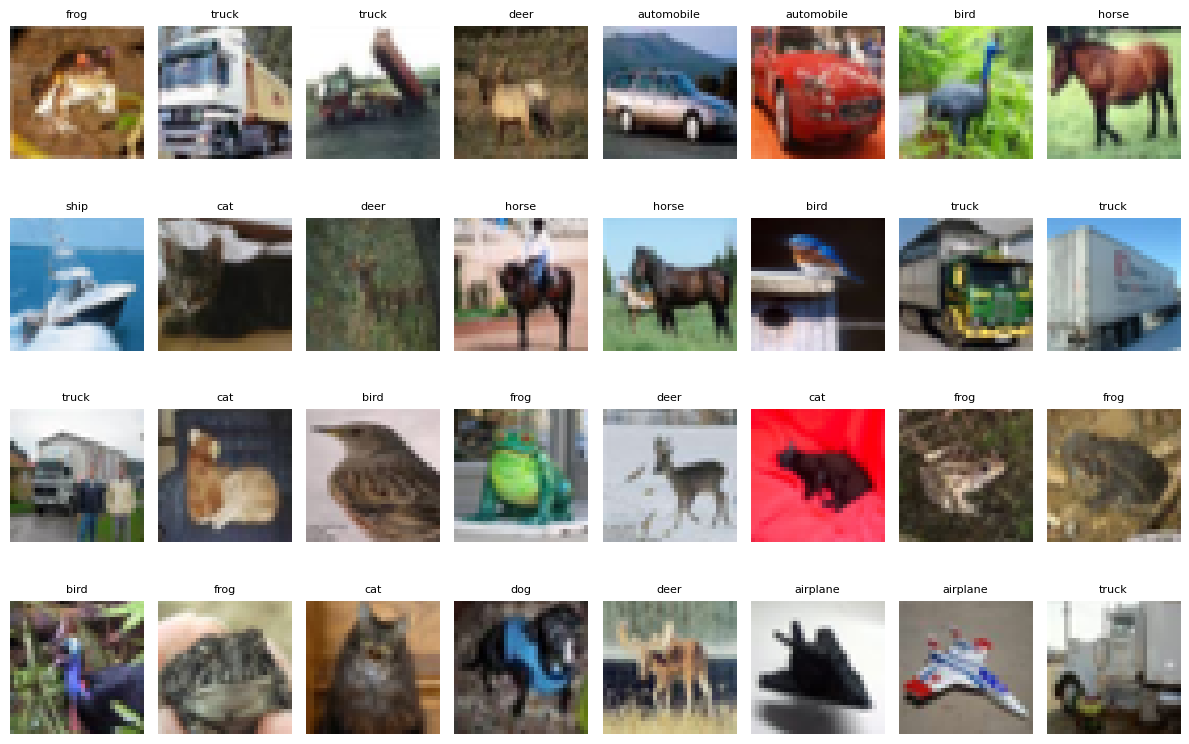

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Define class labels
class_labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Plot the first 32 images with their labels
plt.figure(figsize=(12, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_labels[y_train[i][0]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Visualizing Tensors

Aside from visualizing linear functions and images, we can also visualize entire tensors from DL models.

In [ ]:
# first, let's download an existing model to inspect
model = tf.keras.applications.VGG16(weights='imagenet')

# can then print the summary of what the model is composed of
print(model.summary())

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# we can also print the model layers based on index to better understand the structure
for i,layer in enumerate(model.layers):
  print(f"{i}: {layer}")

0: <InputLayer name=input_layer, built=True>
1: <Conv2D name=block1_conv1, built=True>
2: <Conv2D name=block1_conv2, built=True>
3: <MaxPooling2D name=block1_pool, built=True>
4: <Conv2D name=block2_conv1, built=True>
5: <Conv2D name=block2_conv2, built=True>
6: <MaxPooling2D name=block2_pool, built=True>
7: <Conv2D name=block3_conv1, built=True>
8: <Conv2D name=block3_conv2, built=True>
9: <Conv2D name=block3_conv3, built=True>
10: <MaxPooling2D name=block3_pool, built=True>
11: <Conv2D name=block4_conv1, built=True>
12: <Conv2D name=block4_conv2, built=True>
13: <Conv2D name=block4_conv3, built=True>
14: <MaxPooling2D name=block4_pool, built=True>
15: <Conv2D name=block5_conv1, built=True>
16: <Conv2D name=block5_conv2, built=True>
17: <Conv2D name=block5_conv3, built=True>
18: <MaxPooling2D name=block5_pool, built=True>
19: <Flatten name=flatten, built=True>
20: <Dense name=fc1, built=True>
21: <Dense name=fc2, built=True>
22: <Dense name=predictions, built=True>


Not all of these layers contain weights, for example, MaxPooling2D is a stateless operation, and so is Flatten.
Conv2D and Dense are the two layer types that can be visualized.
That said, let's visualize the filter kernels in the first convolutional layer.

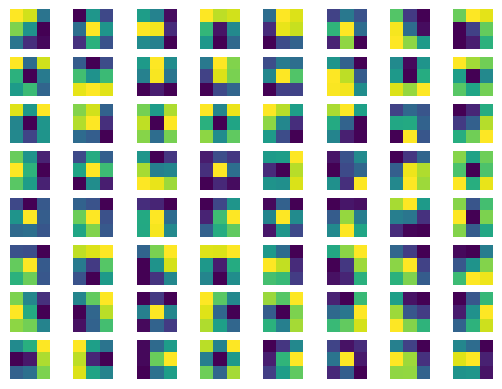

In [ ]:
# next we can extract som
layer = model.layers[1] # Get the first convolutional layer
weights = layer.get_weights()[0]

n_filters = weights.shape[-1]

for i in range(n_filters):
    plt.subplot(8, 8, i+1)  # Assuming 64 filters, adjust if necessary
    plt.imshow(weights[:, :, 0, i], cmap="viridis")
    plt.axis('off')

Aside from visualizing the weights directly, we can also compute and visualize the weight distribution using a histogram.

weight tensor has mean: -0.0024379086680710316 and variance: 0.04272466152906418


(array([ 1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  2.,
         2.,  7.,  2.,  4.,  7.,  6.,  6., 11.,  7.,  9., 12.,  6.,  9.,
        17., 11., 14., 10., 23., 18., 14., 15., 25., 20., 25., 38., 35.,
        38., 44., 32., 41., 42., 44., 38., 36., 32., 42., 40., 31., 23.,
        52., 32., 28., 52., 35., 24., 26., 40., 44., 45., 46., 43., 43.,
        42., 31., 24., 25., 18., 26., 23., 16., 18., 14., 15., 16.,  7.,
        10., 12., 14., 10.,  5.,  9., 10.,  3.,  7.,  4.,  2.,  1.,  2.,
         3.,  2.,  2.,  1.,  1.,  1.,  1.,  0.,  1.]),
 array([-0.67140007, -0.65860093, -0.64580172, -0.63300258, -0.62020344,
        -0.60740429, -0.59460509, -0.58180594, -0.5690068 , -0.55620766,
        -0.54340845, -0.53060931, -0.51781017, -0.50501096, -0.49221182,
        -0.47941267, -0.4666135 , -0.45381436, -0.44101518, -0.42821604,
        -0.41541687, -0.40261772, -0.38981855, -0.37701941, -0.36422023,
        -0.35142106, -0.33862191, -0.32582274, -0.3130236 , -0.300224

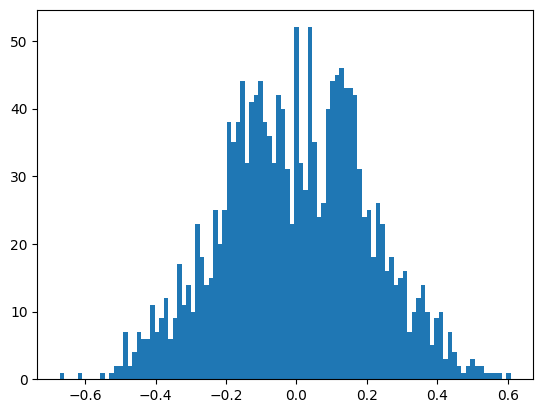

In [ ]:

# we can use the mean and var (variance) functions built in to calculate some simple statistics
print(f"weight tensor has mean: {weights.mean()} and variance: {weights.var()}")

# we need to call .flatten() on the tensor so that all the histogram sees them as a 1D array. Then we can plot with 100 bins to get a bit more resolution in the histogram.
plt.hist(weights.flatten(), bins=100)

**Question 4**

Look through the other weight tensors in the network and note any patterns that can be observed. In the cell below please plot some examples in a subplot grid (include at least 4 plots).
You can also overplot on the same subplot if you find that helpful for visualization.

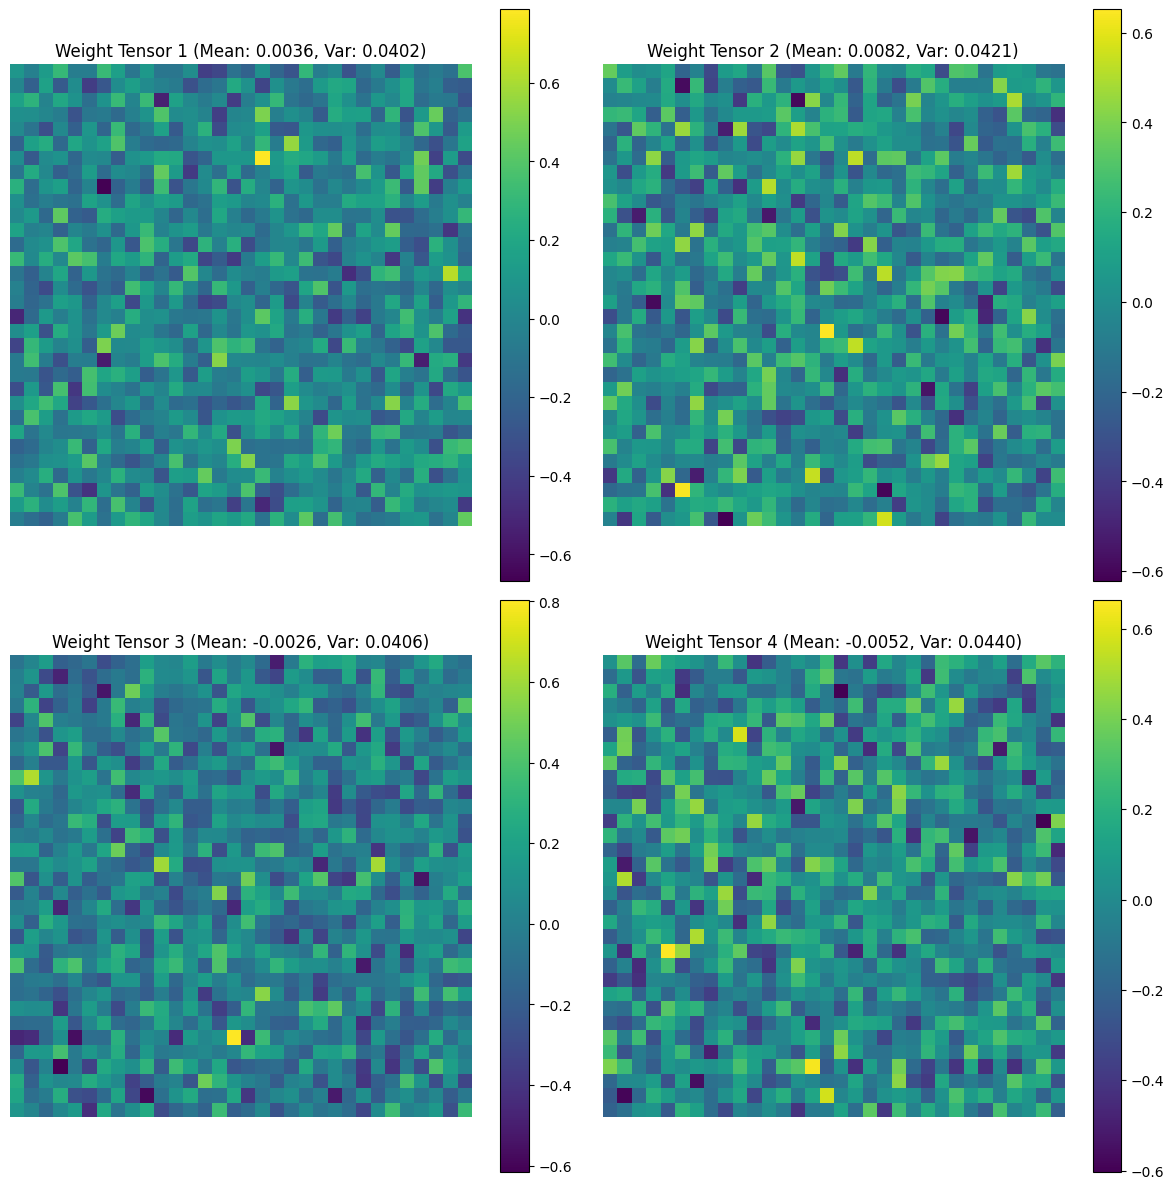

In [ ]:
# Simulating weight tensors with similar statistical properties (mean and variance)
np.random.seed(42)  # For reproducibility
weights_1 = np.random.normal(loc=-0.0024, scale=np.sqrt(0.042), size=(32, 32))
weights_2 = np.random.normal(loc=-0.0024, scale=np.sqrt(0.042), size=(32, 32))
weights_3 = np.random.normal(loc=-0.0024, scale=np.sqrt(0.042), size=(32, 32))
weights_4 = np.random.normal(loc=-0.0024, scale=np.sqrt(0.042), size=(32, 32))

# Create a subplot grid to visualize the weights
plt.figure(figsize=(12, 12))

# Plot each weight tensor
for i, weights in enumerate([weights_1, weights_2, weights_3, weights_4], start=1):
    plt.subplot(2, 2, i)
    plt.imshow(weights, cmap="viridis")
    plt.colorbar()
    plt.title(f"Weight Tensor {i} (Mean: {weights.mean():.4f}, Var: {weights.var():.4f})")
    plt.axis("off")

plt.tight_layout()
plt.show()


We can also visualize the activations within the network, this is done by applying a forward pass with a data input, and extracting the intermediate result. Below is an example output from the first convolution layer.

1/1 [==============================] - 0s 267ms/step


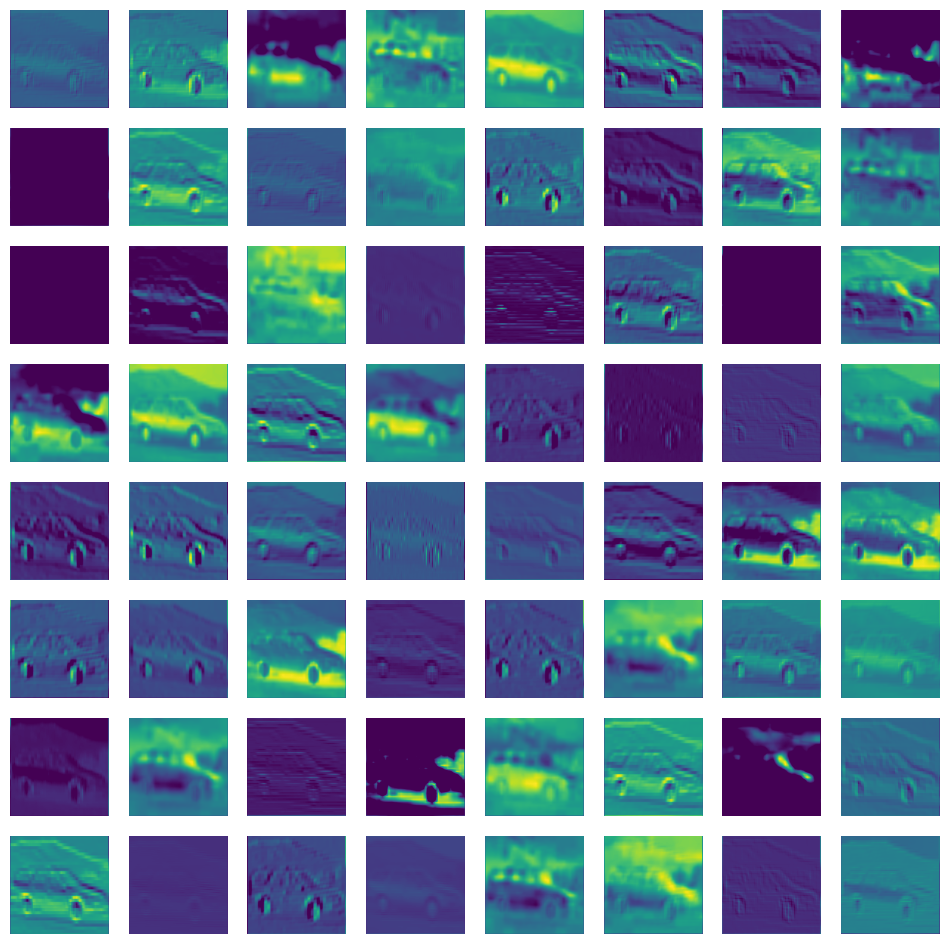

In [ ]:
# Resize and normalize the images to be suitable for VGG16
train_images_resized = tf.image.resize(train_images[4:5], [224, 224])

# Normalize the pixel values to [0,1]
train_images_resized = train_images_resized / 255.0

layer = model.layers[1] # Get the first convolutional layer
intermediate_layer_model = tf.keras.models.Model(inputs=model.input, outputs=layer.output)
activation = intermediate_layer_model.predict(train_images_resized)

# get the feature count from the activations
n_features = activation.shape[-1]

# Set the figure size
plt.figure(figsize=(12, 12))

for i in range(n_features):
    plt.subplot(8, 8, i+1)  # Assuming 64 features, adjust if necessary
    plt.imshow(activation[0, :, :, i], cmap="viridis")
    plt.axis('off')

**Question 5**

In the cell below reuse the code above for the forward pass, and the layer indices, to plot the activation distributions for the final three dense layers.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step


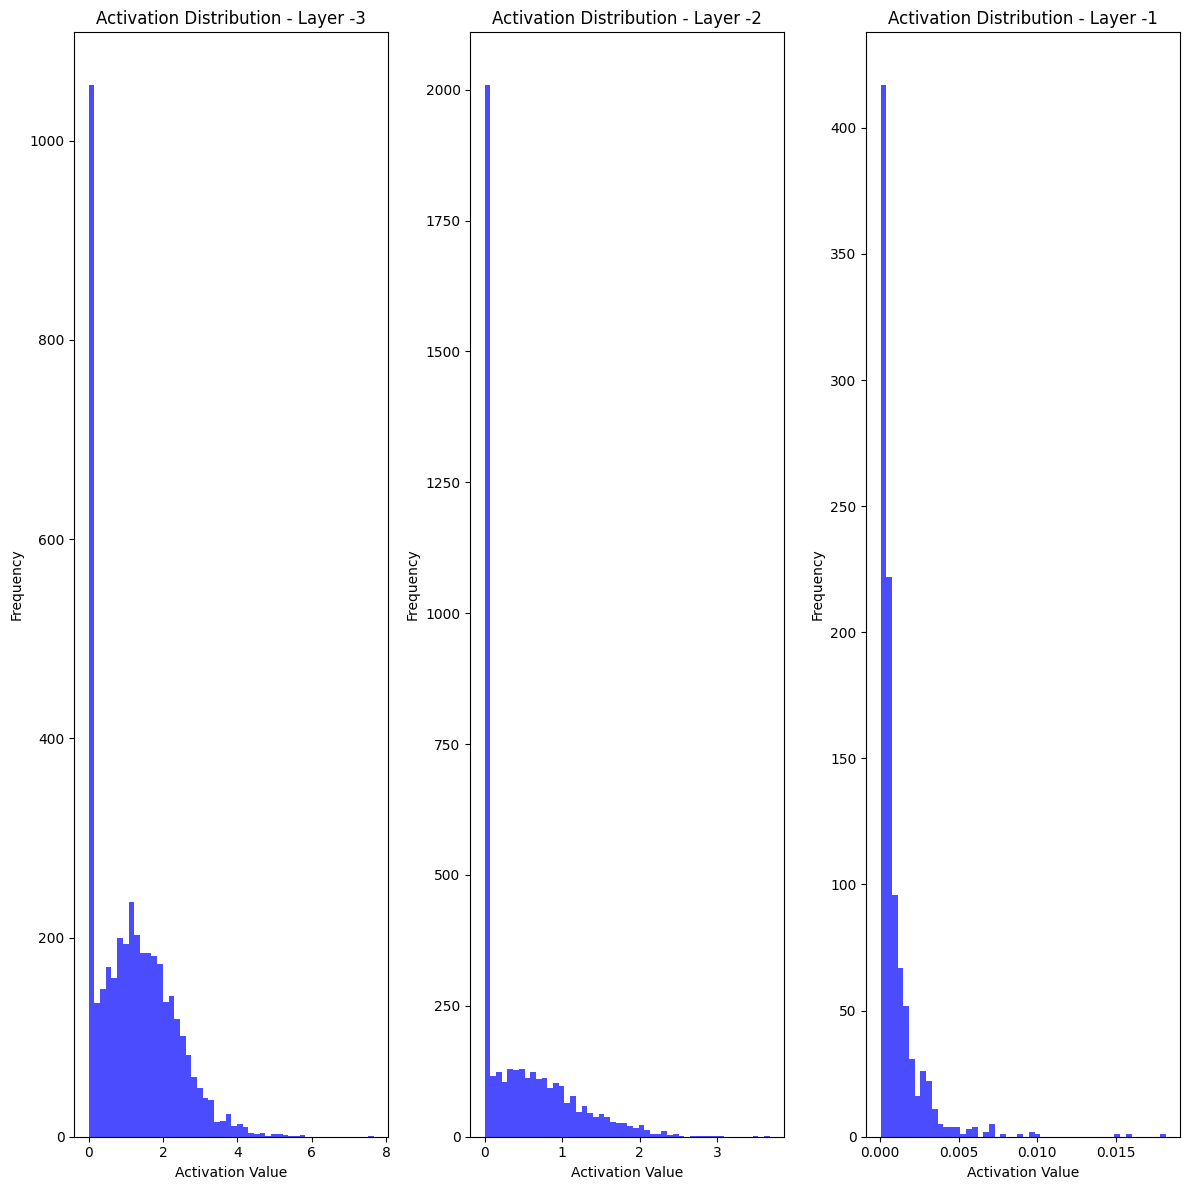

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the pre-trained VGG16 model
model = tf.keras.applications.VGG16(weights='imagenet', include_top=True)

# Load CIFAR-10 dataset as an example
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize the images to [0, 1]
train_images = train_images / 255.0

# Resize a specific image from the training set to 224x224
train_images_resized = tf.image.resize(train_images[4:5], [224, 224])

# Forward pass to get activations from the final three dense layers
dense_layer_indices = [-3, -2, -1]  # Indices of the last three dense layers

# Set the figure size for plotting the activations
plt.figure(figsize=(12, 12))

for i, layer_index in enumerate(dense_layer_indices):
    # Get the layer
    layer = model.layers[layer_index]

    # Create a model that outputs the activations for this layer
    intermediate_layer_model = tf.keras.models.Model(inputs=model.input, outputs=layer.output)

    # Get activations for the resized image
    activation = intermediate_layer_model.predict(train_images_resized)

    # Flatten the activations to 1D for plotting distributions
    flattened_activation = activation.flatten()

    # Plot the activation distribution for this layer
    plt.subplot(1, 3, i+1)
    plt.hist(flattened_activation, bins=50, color="blue", alpha=0.7)
    plt.title(f"Activation Distribution - Layer {layer_index}")
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


**Question 6**

What do you notice about the distributions, and how they compare to those of the weight tensors?

1. Activation Distributions:
Shape and Spread: The activation values in the dense layers often exhibit a distribution that tends to be more concentrated around a certain range, with a relatively small spread. This is often due to the activation functions used (like ReLU or softmax) which can clip values to a certain range, leading to a more centered or squashed distribution.
Effect of Non-Linearities: The presence of activation functions like ReLU or sigmoid can significantly impact the distribution of activations. For example, ReLU activations will produce a distribution with many values centered around 0 (for the "inactive" neurons) and positive values (for the active ones). In contrast, sigmoid activations tend to concentrate activations around 0 and 1, creating a more bimodal distribution.
Sparsity: In many models, especially with ReLU activations, a significant proportion of activations might be 0 (inactive), leading to a sparse activation distribution. This can indicate that many neurons are not being activated during the forward pass.
2. Weight Tensor Distributions:
Initialization Influence: Weight tensors typically start with random values when using common initialization methods like Xavier (Glorot) or He initialization. These initial weight distributions are usually centered around 0 with some variance, and their distribution depends on the initialization scheme. Xavier initialization tends to produce weights with a distribution centered around 0, with variance designed to maintain the signal scale across layers.
Weight Updates During Training: As training progresses, the weight distribution evolves. The updates are typically influenced by the loss function and gradients, with weights potentially becoming more tightly clustered as training converges, especially when using regularization techniques like L2 regularization. The distribution of weights after training might appear less random and more structured.
Magnitude of Weights: Weights generally follow a distribution that might have a wider spread compared to activations, especially in the early layers. This can be because of the scaling of activations and the impact of the backpropagation mechanism.
3. Comparing Activations and Weights:
Distribution Characteristics:
The weight distribution is typically more spread out or varied than the activations, as weights are initialized randomly and continuously updated during training. In contrast, activations tend to become more concentrated due to the activation functions (e.g., ReLU or softmax).
Weights often follow a roughly Gaussian distribution, especially when using certain initialization schemes, whereas activations, particularly with ReLU, may show sparsity with many 0s.
Impact of Activations on Weights:
In the case of activation functions like ReLU, the weights are adjusted to maximize the activations in response to input data. This results in weights that are often less sparsely distributed than activations.
Weight values directly influence the scale of activations, and these activations can impact how much information is passed forward in the network. Dense layers rely heavily on the weights, which are learned during training to map inputs to the correct output.
Sparsity:
Weight tensors are often less sparse than activations. However, sparsity in weights can occur due to regularization techniques (e.g., L1 regularization). Activations are usually more sparse, especially in layers with ReLU activation, where many neurons do not fire (output 0).
Magnitude:
Weight magnitudes can vary significantly from layer to layer, especially in deeper networks. The activations, on the other hand, are often constrained by the nature of the activation function (e.g., a sigmoid function squashes values to a [0,1] range).